Loading BokehJS ...

Loaded 'examples_audio/Dufour_full_mono.aif' -> 77.667s @ 44100Hz


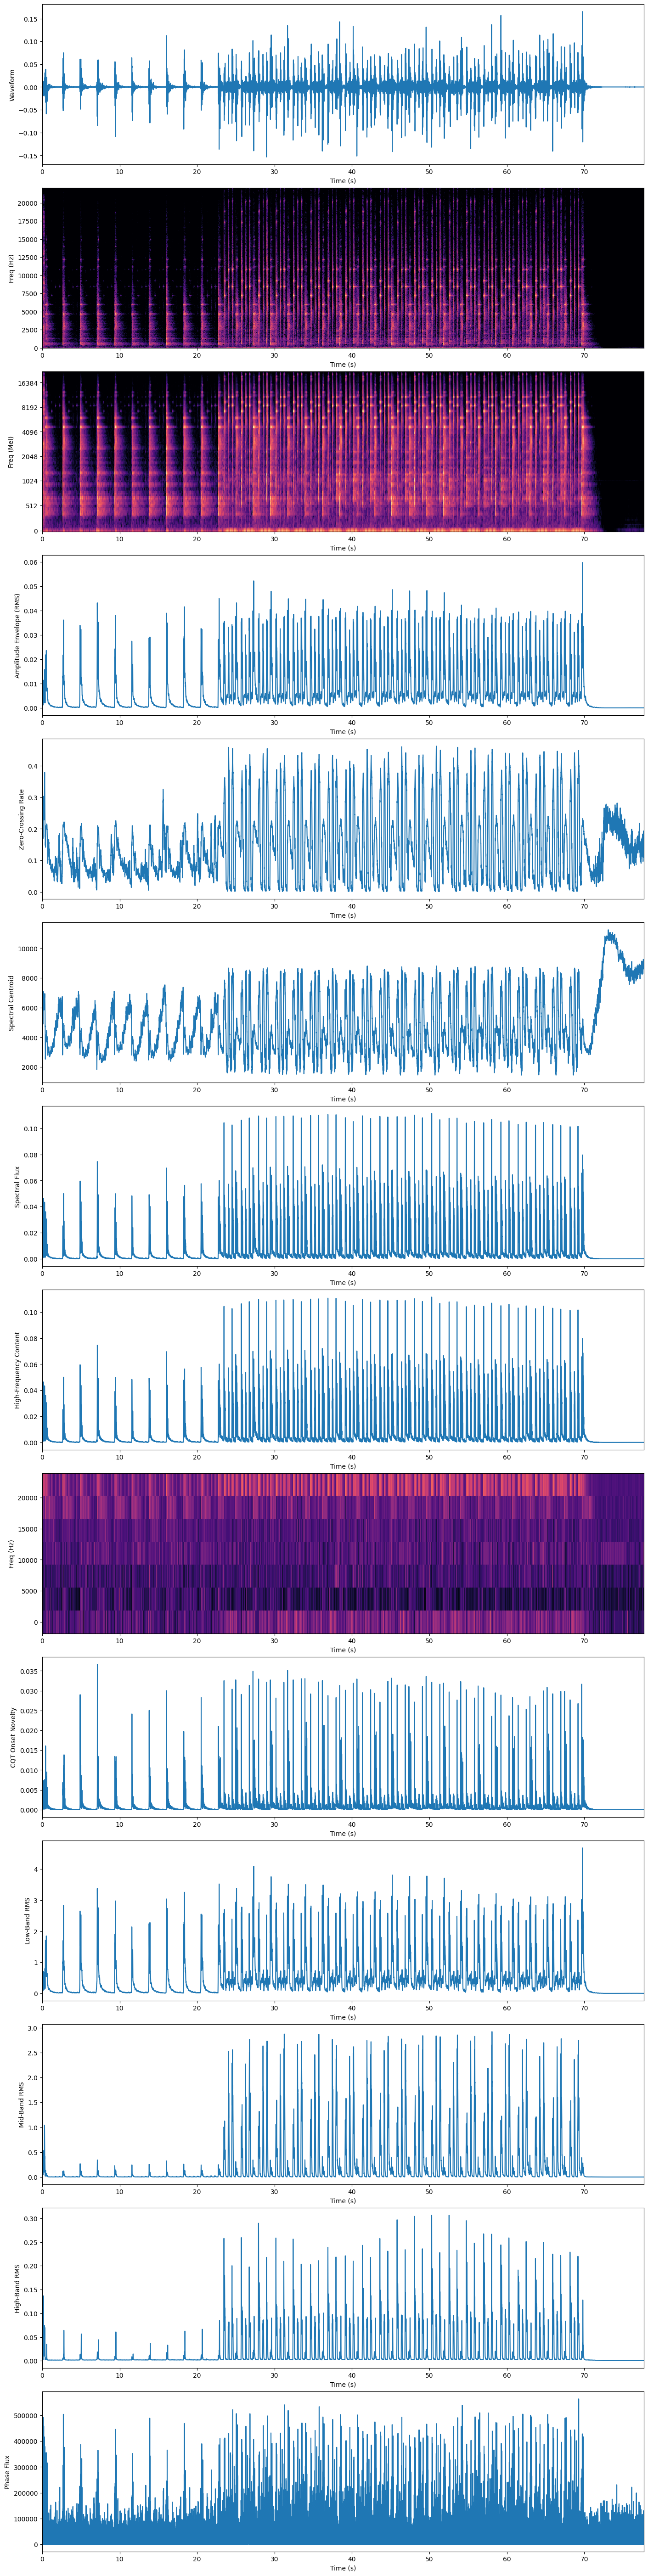

In [3]:
# Import the necessary functions from your module
from py_scripts.audio_visualizer import load_audio, extract_features, visualize_features
import numpy as np

# --- BOKEH SETUP ---
from bokeh.io import output_notebook
output_notebook()
# --- END BOKEH SETUP ---

# --- CONFIGURATION ---
AUDIO_PATH = 'examples_audio/Dufour_full_mono.aif'
HOP_LENGTH = 128
N_FFT = 2048

# --- TIME RANGE ---
# Format: "HH:MM.SS-HH:MM.SS"
# Example: "00:00.000-00:20.000"
# If you want to plot the entire audio, use "None"
# If you want to plot a specific part of the audio, use the start and end times

TIME_RANGE = None 

# 1. Load the audio file
y, sr = load_audio(AUDIO_PATH, time_range=TIME_RANGE)

# 2. Define which features you want to compute and plot

# Features: 'waveform', 'stft_db', 'amplitude_envelope', 'zero_crossing_rate', 
# 'spectral_centroid', 'spectral_flux', 'high_frequency_content', 'spectral_contrast', 'cqt_flux', 
# 'melspectrogram', 'rms_low', 'rms_mid', 'rms_high'

FEATURES_TO_PLOT = ['waveform', 'stft_db', 'melspectrogram', 'amplitude_envelope', 'zero_crossing_rate', 
'spectral_centroid', 'spectral_flux', 'high_frequency_content', 'spectral_contrast', 'cqt_flux', 
'rms_low', 'rms_mid', 'rms_high', 'phase_flux']

# 3. COMPUTE THE FEATURES from the audio signal
# This will return a dictionary like {'waveform': [...], 'stft_db': [...], ...}
feature_data = extract_features(
    y=y,
    sr=sr,
    hop_length=HOP_LENGTH,
    n_fft=N_FFT
)

# 4. Set the backend for the inline display: 'matplotlib' or 'bokeh'
PLOTTING_BACKEND = 'matplotlib'

# 5. Plot the computed features
visualize_features(
    features=feature_data,              
    sr=sr,
    hop_length=HOP_LENGTH,
    features_to_plot=FEATURES_TO_PLOT,
    backend=PLOTTING_BACKEND,
    time_range=TIME_RANGE           
)
